### This notebook compute "E7. Number of infrastructure for the provision of drinking water exposed to climate hazards" indicator for the 27 basins of IKI Project

Spanish: Número de obras de infraestructura para la provisión de agua potable expuesta a peligros climáticos

**Created:** 8/10/2025 by Serena Gilson (sgilson@rti.org)

**Project #:** 0219481  

**Last modified:** Sophia Bakar (sbakar@rti.org)

**Status:** Completed and loaded in SQLite database for the baseline and first future scenario. 

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\Scripts_Exposure 
 
**Inputs:**   • Embalses_IKI.shp (downlaoded from RTI (constriuido de varios fuentes inclutendo db de ANA, WEAP, y ) and cropped) 
• PTAPs (from Viviendas (hay que solicitar) and 
    • SUNASS\BDGIS.gdb, layer= EPS_PTAP
    • SUNASS\BDGIS.gdb, layer= noEPS_PTAP
    • SUNASS\BDGIS.gdb, layer= EPS_Captaciones
    - SUNASS\BDGIS.gdb, layer= noEPS_Captaciones  

**Packages:** numpy, pandas, geopandas, sqlite3, matplotlib  
 
**Assumptions:** COMIDs that do not have any infrastructure will be populated with NaN
 
**N/A Handling:** Replace zeros with NaN. 

**Future work:** 
 
**Notes:** 

General Methodology:  
1. Combine all infrastructure layers into a single object.  
2. Spatial join infrastructure with COMIDs.  
3. Calculate the total number of infrasturcture features per COMID.  

INPUTS

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 207 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [4]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#sunass_gdb = rf'C:\Users\{user\Research Triangle Institute\IKI Peru Project - General\Interno\GIS\4_DEMANDAS_DEMANDS\SUNASS\BDGIS.gdb'
sunass_gbd = fr'C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\4_DEMANDAS_DEMANDS\SUNASS\BDGIS.gdb'

#embalses = rf'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\embalses_IKI.shp'
embalses = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\embalses_IKI.shp"


In [5]:
#read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in SUNASS geodf
EPS_PTAPs= gpd.read_file(sunass_gbd, layer= 'EPS_PTAP').to_crs('EPSG:32718')
noEPS_PTAPs= gpd.read_file(sunass_gbd, layer= 'NOEPS_PTAP').to_crs('EPSG:32718')
EPS_Captaciones= gpd.read_file(sunass_gbd, layer= 'EPS_CAPTACION').to_crs('EPSG:32718')
noEPS_Captaciones= gpd.read_file(sunass_gbd, layer= 'NOEPS_CAPTACION').to_crs('EPSG:32718')

#read in reservoirs, #determine what the original layer for this is
embalses= gpd.read_file(embalses).to_crs('EPSG:32718')


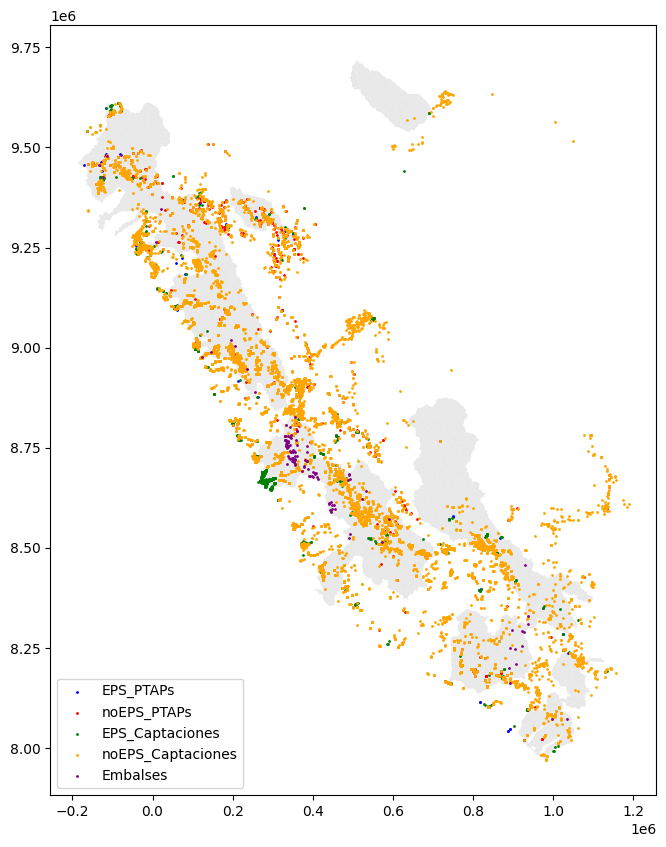

In [6]:
#plot EPS_PTAPs, noEPS_PTAPs, EPS_Captaaciones, noEPS_captaciones, embalses and subbasins_gdf
#change point size to smaller 
fig, ax = plt.subplots(figsize=(10, 10))
subbasins_gdf.plot(ax=ax, color='lightgrey', edgecolor='none', alpha=0.5)
EPS_PTAPs.plot(ax=ax, color='blue', markersize= 1, label='EPS_PTAPs')
noEPS_PTAPs.plot(ax=ax, color='red', markersize= 1, label='noEPS_PTAPs')
EPS_Captaciones.plot(ax=ax, color='green', markersize= 1,label='EPS_Captaciones')
noEPS_Captaciones.plot(ax=ax, color='orange',markersize= 1, label='noEPS_Captaciones')
embalses.plot(ax=ax, color='purple', markersize= 1, label='Embalses')
plt.legend()
plt.show()

In [9]:
infrastructure_layers = [
    EPS_PTAPs,
    noEPS_PTAPs,
    EPS_Captaciones,
    noEPS_Captaciones,
    embalses]

target_crs = subbasins_gdf.crs

# --- Combine infrastructure layers ---
all_infrastructure = gpd.GeoDataFrame(
    pd.concat(infrastructure_layers, ignore_index=True),
    crs=target_crs
)

print(f"Total infrastructure features: {len(all_infrastructure)}")

# --- Spatial join ---
infrastructure_counts = gpd.sjoin(
    all_infrastructure,
    subbasins_gdf[['COMID', 'geometry']],
    how='left',
    predicate='intersects'  # safer than 'within'
)

# --- Count infrastructure per COMID ---
counts_by_comid = (
    infrastructure_counts
    .groupby('COMID_right')
    .size()
    .reset_index(name='total_infrastructure')
    .rename(columns={'COMID_right': 'COMID'})
)

print(f"COMIDs with ≥1 infrastructure feature: {len(counts_by_comid)}")

# --- Merge back to subbasins ---
subbasins_with_counts = subbasins_gdf.merge(
    counts_by_comid,
    on='COMID',
    how='left'
)

# --- Explicitly convert 0 → NaN ---
subbasins_with_counts['total_infrastructure'] = (
    subbasins_with_counts['total_infrastructure']
    .replace(0, np.nan)
)

# --- Diagnostics ---
print(f"Total COMIDs: {len(subbasins_with_counts)}")
print(f"COMIDs with infrastructure: {subbasins_with_counts['total_infrastructure'].notna().sum()}")
print(f"COMIDs without infrastructure (NaN): {subbasins_with_counts['total_infrastructure'].isna().sum()}")


Total infrastructure features: 11510
COMIDs with ≥1 infrastructure feature: 979
Total COMIDs: 3655
COMIDs with infrastructure: 979
COMIDs without infrastructure (NaN): 2676


<Axes: >

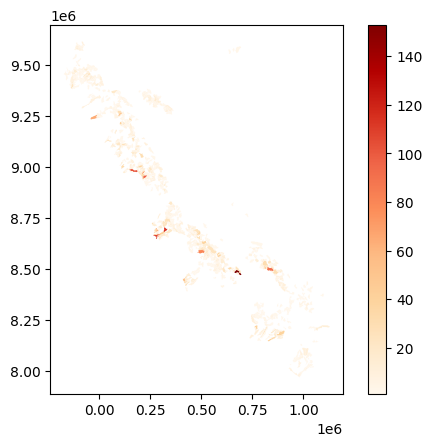

In [10]:
subbasins_with_counts.plot(column='total_infrastructure', cmap='OrRd', legend=True)

SQLITE INSERT 

In [11]:
# insert results into the database 
insert_data= subbasins_with_counts #COMID 
value_column= 'total_infrastructure' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [12]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_with_counts['total_infrastructure']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 207  Min: 0, Max: 10000000

=== Values to be inserted (by scenario) ===
   index  total_infrastructure
0    min                   1.0
1    max                 153.0
2  count                 979.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [13]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()